In [14]:
import matplotlib.pyplot as plt
import pandas as pd

In [15]:
df = pd.read_csv("fifa_world_cup_2026_player_performance.csv")

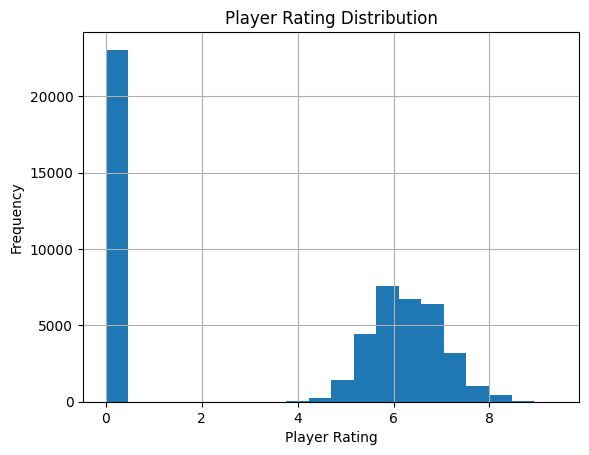

In [16]:
df["player_rating"].hist(bins=20)
plt.title("Player Rating Distribution")
plt.xlabel("Player Rating")
plt.ylabel("Frequency")
plt.show()

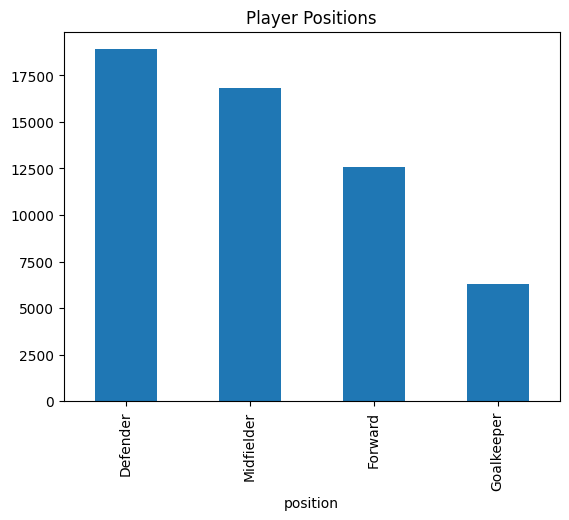

In [17]:
df["position"].value_counts().plot(kind="bar")
plt.title("Player Positions")
plt.show()

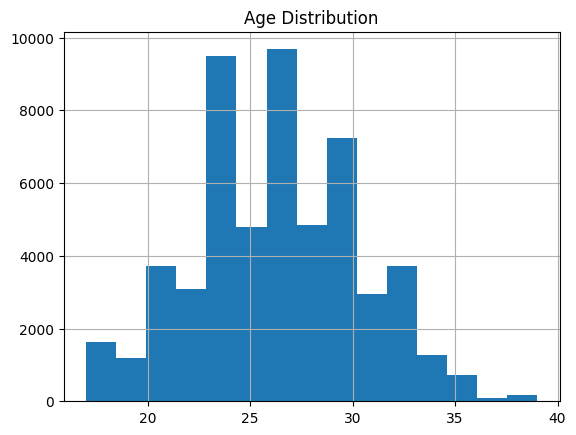

In [18]:
df["age"].hist(bins=15)
plt.title("Age Distribution")
plt.show()

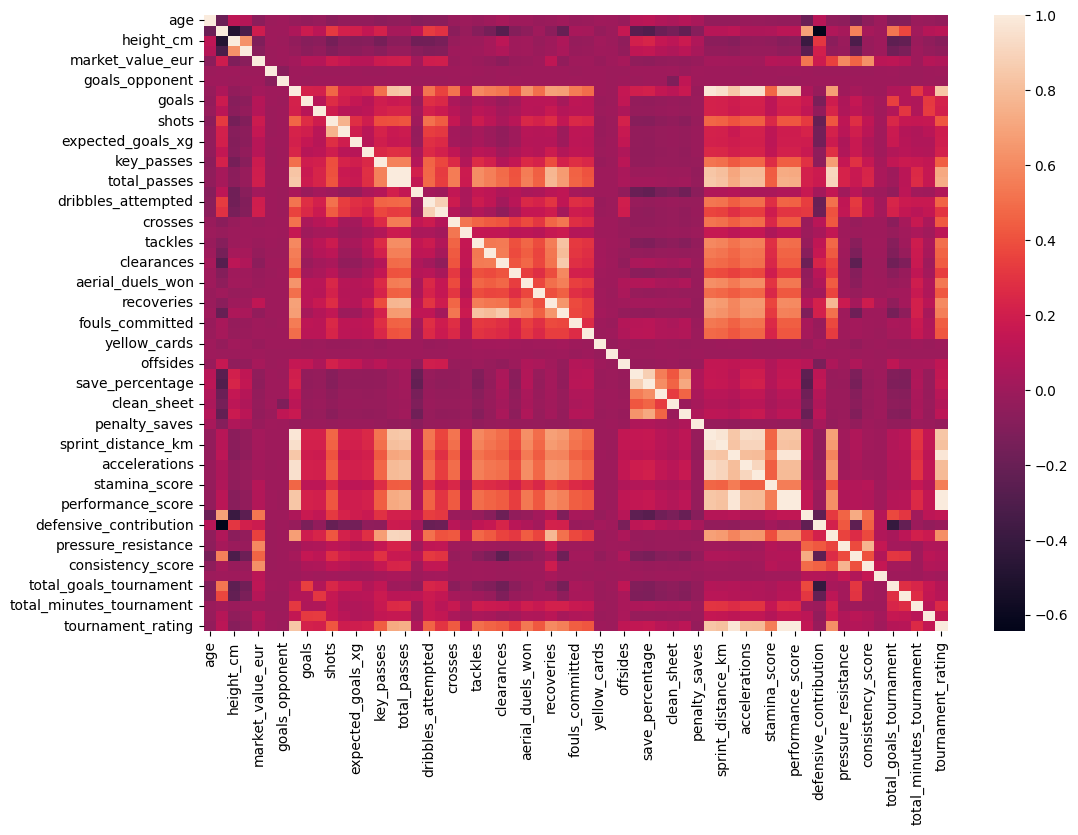

In [19]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include="number").corr())
plt.show()

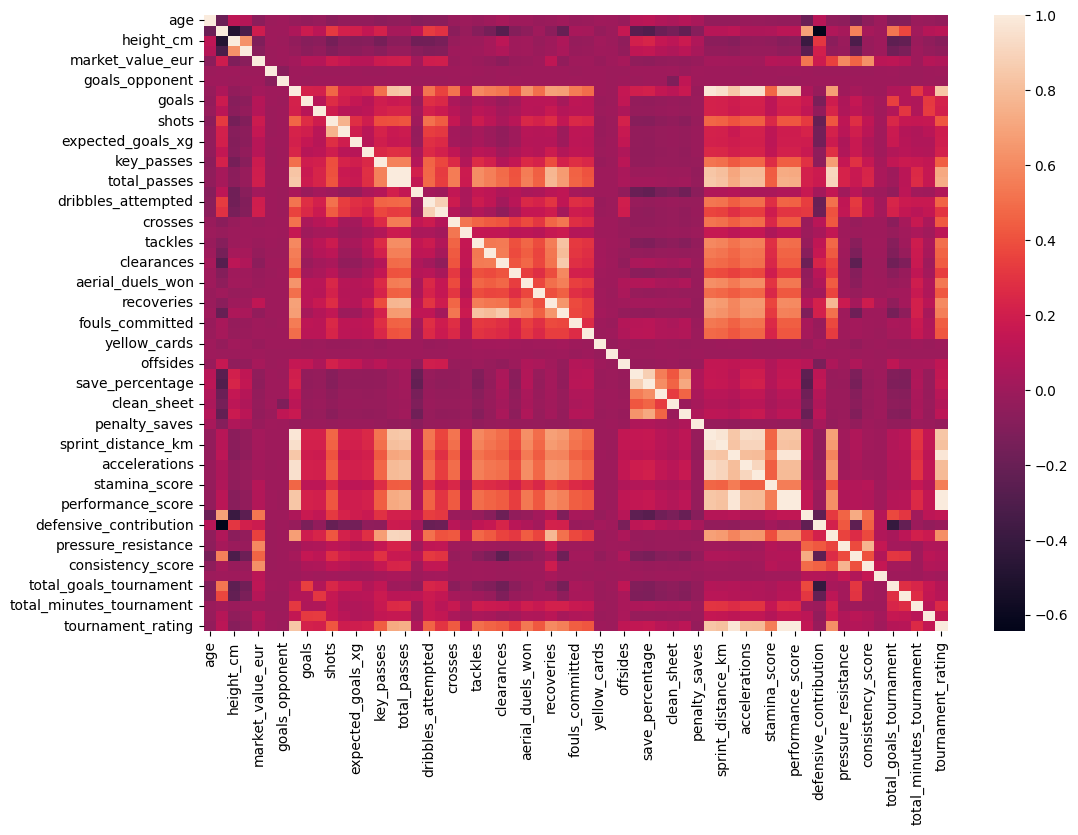

In [20]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include="number").corr())
plt.show()

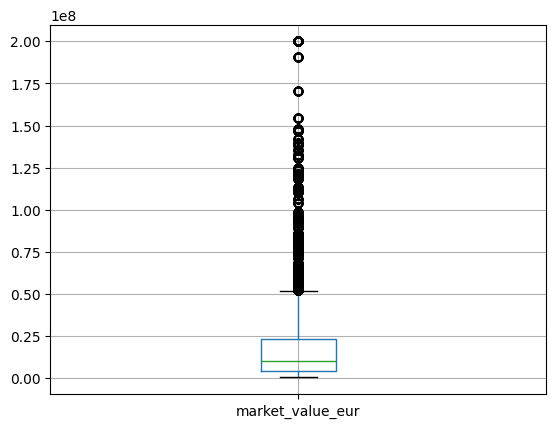

In [21]:
df.boxplot(column="market_value_eur")
plt.show()

In [22]:
df.isnull().sum().sort_values(ascending=False).head(10)

player_id         0
player_name       0
age               0
nationality       0
team              0
jersey_number     0
position          0
height_cm         0
weight_kg         0
preferred_foot    0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
# Phase 5 - Data Cleaning
columns_to_drop = [
    "player_id",
    "player_name",
    "match_id"
]

df = df.drop(columns=columns_to_drop)

df["match_date"] = pd.to_datetime(df["match_date"])

df.info()
df = df[df["player_rating"] > 0]
# Players with a rating of 0 were removed because they likely did not participate sufficiently in the match and do not contribute meaningful information for predicting player ratings.
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 72 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   age                       54600 non-null  int64         
 1   nationality               54600 non-null  object        
 2   team                      54600 non-null  object        
 3   jersey_number             54600 non-null  int64         
 4   position                  54600 non-null  object        
 5   height_cm                 54600 non-null  int64         
 6   weight_kg                 54600 non-null  int64         
 7   preferred_foot            54600 non-null  object        
 8   club_name                 54600 non-null  object        
 9   market_value_eur          54600 non-null  int64         
 10  match_date                54600 non-null  datetime64[ns]
 11  stadium                   54600 non-null  object        
 12  city              

(31558, 72)

In [25]:
df.to_csv(
"../data/football_dataset_cleaned.csv",
index=False
)

In [26]:
columns_to_drop = [
    "jersey_number",
    "stadium",
    "city",
    "match_date",
    "club_name",
    "market_value_eur",
    "performance_score",
    "offensive_contribution",
    "defensive_contribution",
    "creativity_score",
    "consistency_score",
    "clutch_performance_score",
    "tournament_rating"

]

df = df.drop(columns=columns_to_drop)
df.shape

(31558, 59)

In [27]:
df.to_csv("../data/football_dataset_cleaned.csv", index=False)